## DSCI 552 Homework 2

**Name:** Rodrigo Garcia

**Github:** garciar8-port

**USC ID:** 2105066875

imports below (also in requirements.txt -> `pip install -r requirements.txt`)

In [1]:
#alt to running requirements install in terminal
import sys
!{sys.executable} -m pip install -r requirements.txt

In [2]:
#import packages
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

#Used for split in 1(h)
SEED = 875
np.random.seed(SEED)

def format_number(value):
    return f"{value:.4g}"

pd.set_option("display.float_format", format_number)


## 1. Combined Cycle Power Plant Data Set

### 1(a) - data

Load Sheet1 of the CCPP workbook (footnote 1: all five sheets are shuffled copies of the same data). Relative path, forward slashes.

In [3]:
df = pd.read_excel("data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024,73.17,463.3
1,25.18,62.96,1020,59.08,444.4
2,5.11,39.4,1012,92.14,488.6
3,20.86,57.32,1010,76.64,446.5
4,10.82,37.5,1009,96.62,473.9


### 1(b) - Exploring the data

i.) How many rows and columns? What do the rows and columns represent?

In [4]:
print("Rows, Columns:", df.shape, "where the rows are hourly averages of plant ops and columns are the measured variables per hour (AT, V, AP, RH) and the output (PE)")

missing_vals_by_column = df.isnull().sum()
missing_count = missing_vals_by_column.sum()
print("Missing Values:", int(missing_count))
dups = df.duplicated().sum()
print("Duplicated Values:", int(dups))

df.dtypes


Rows, Columns: (9568, 5) where the rows are hourly averages of plant ops and columns are the measured variables per hour (AT, V, AP, RH) and the output (PE)
Missing Values: 0
Duplicated Values: 41


AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

So the data spans from 2006-2011, covering 6 years. A total of 9,568 observations were collected during that time for the four measured variables and the output variable. There are no missing values, and there are 41 duplicated values (these are kept, as the reason for their "duplication" is unknown.)

| column | meaning | units |
|---|---|---|
| AT | ambient temperature | °C |
| V | exhaust vacuum (steam turbine side) | cm Hg |
| AP | ambient pressure | mbar |
| RH | relative humidity | % |
| PE | net hourly electrical energy output (response) | MW |



ii.) Pairwise scatterplots of all variables, predictors and response. Describe the findings.

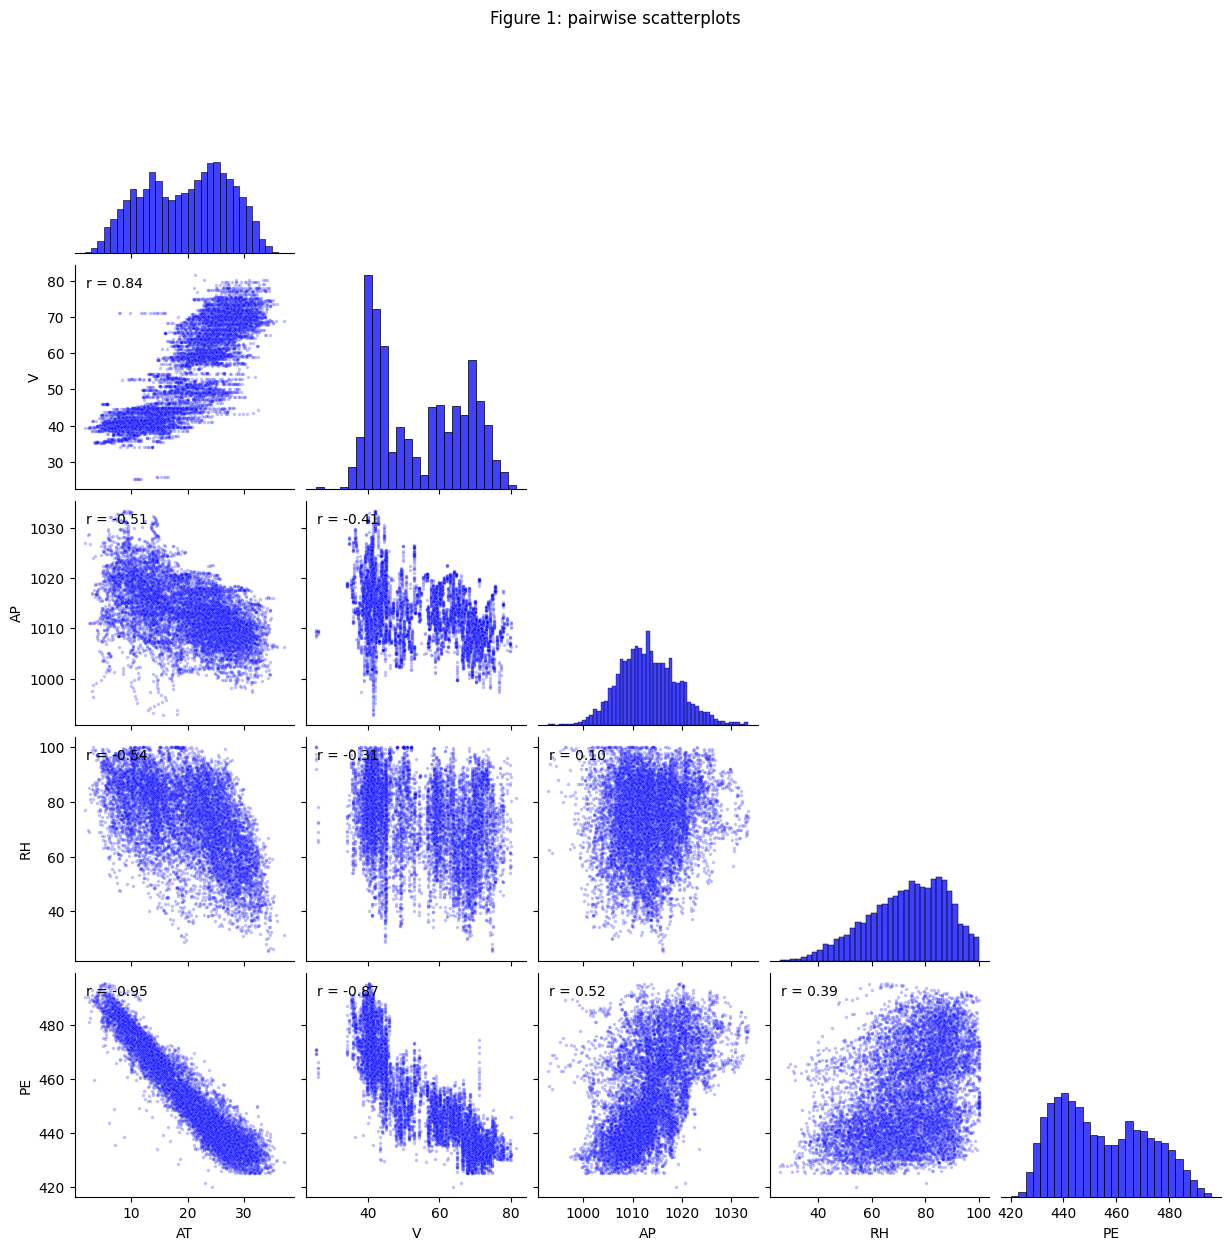

In [5]:
#seaborn scatterplots
def add_r(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.text(0.05, 0.9, f"r = {r:.2f}", transform=ax.transAxes) 

scttrplt = sns.pairplot(df, corner=True, plot_kws={"s": 6, "alpha": 0.25,"color": "blue"}, diag_kws={"color": "blue"})

scttrplt.map_lower(add_r)
scttrplt.figure.suptitle("Figure 1: pairwise scatterplots", y=1.0)
plt.show()

AT and PE have a clear negative correlation followed by V PE.  AP and PE have somewhat of a correlation but remain diffuse, while RH and PE are the least correlated of the four. 

iii.) Mean, median, range, Q1, Q3, and IQR of each variable, summarized in a table.

In [6]:
stats = df.describe()
stats.loc["range"] = stats.loc["max"] - stats.loc["min"]
stats.loc["IQR"] = stats.loc["75%"] - stats.loc["25%"]
stats


,AT,V,AP,RH,PE
count,9568,9568,9568,9568,9568
mean,19.65,54.31,1013,73.31,454.4
std,7.452,12.71,5.939,14.6,17.07
min,1.81,25.36,992.9,25.56,420.3
25%,13.51,41.74,1009,63.33,439.8
50%,20.34,52.08,1013,74.97,451.5
75%,25.72,66.54,1017,84.83,468.4
max,37.11,81.56,1033,100.2,495.8
range,35.3,56.2,40.41,74.6,75.5
IQR,12.21,24.8,8.16,21.5,28.68


### 1(c) - Simple linear regression

Fit a simple linear regression to predict the response for each predictor (aka measured variables). Describe the results. Which models show a statistically significant association between predictor and response? Plots to back this up. Any outliers worth removing for each regression?

In [7]:
predictors = ["AT", "V", "AP", "RH"]
response = "PE"

linear_models = {}
records = {}

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    model = sm.OLS(df[response], X).fit()

    linear_models[predictor] = model
    records[predictor] = {
        "Slope": model.params[predictor],
        "Std error": model.bse[predictor],
        "t": model.tvalues[predictor],
        "p-value": model.pvalues[predictor],
        "R^2": model.rsquared,
    }


table = pd.DataFrame.from_dict(records, orient="index")
table.index.name = "predictor"
table

,Slope,Std error,t,p-value,R^2
predictor,,,,,
AT,-2.171,0.007443,-291.7,0,0.8989
V,-1.168,0.006776,-172.4,0,0.7565
AP,1.49,0.02513,59.3,0,0.2688
RH,0.4557,0.01101,41.4,0,0.1519


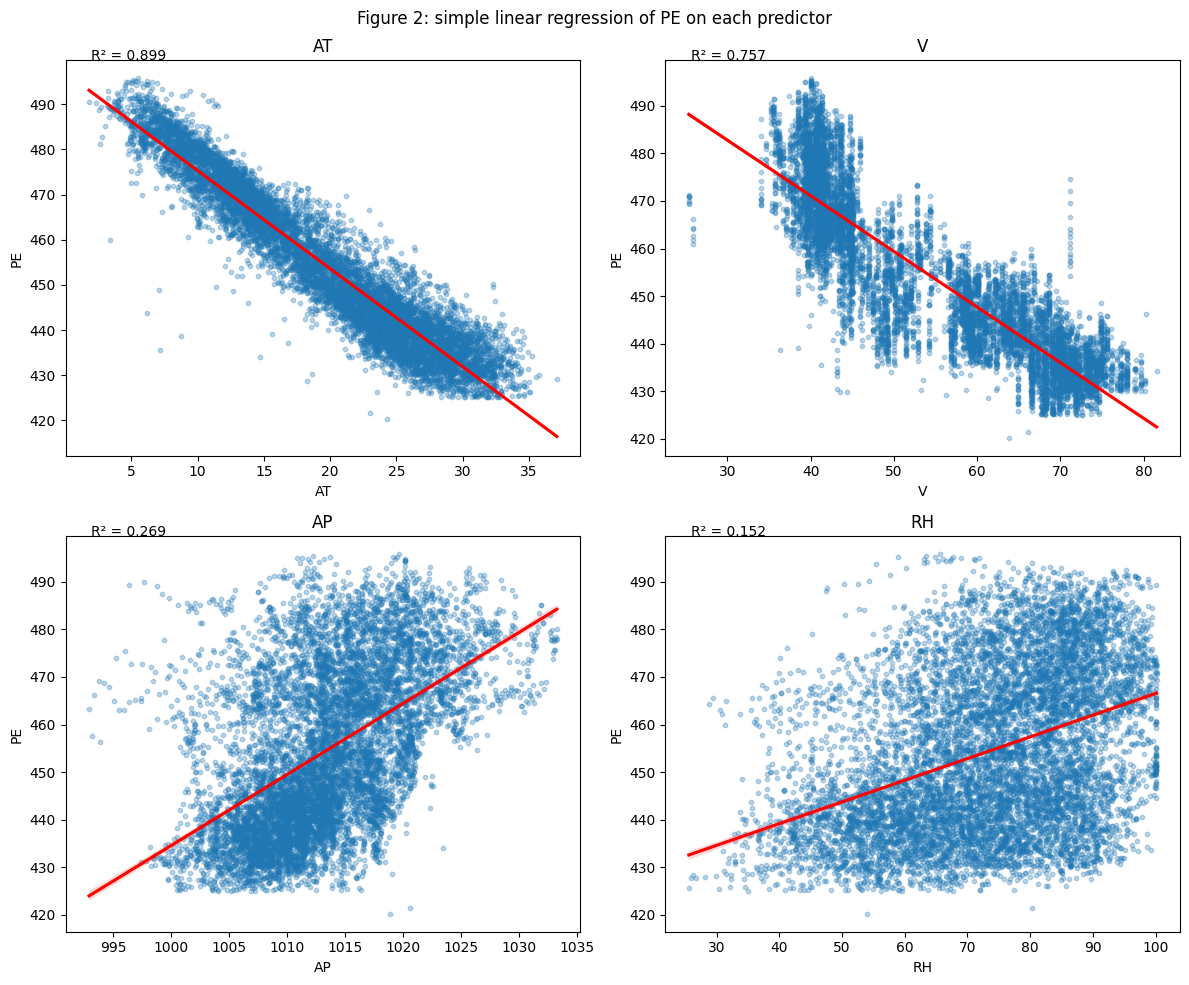

In [8]:
#simple model plots

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle("Figure 2: simple linear regression of PE on each predictor")

for predictor, ax in zip(predictors, axes):
    sns.regplot(
        x=predictor,
        y=response,
        data=df,
        ax=ax,
        scatter_kws={"s": 10, "alpha": 0.3},
        line_kws={"color": "red"} 
    )
    
    ax.set_xlabel(predictor)
    ax.set_ylabel(response)
    ax.set_title(f"{predictor}")
    ax.text(0.05, 1.0, f"R² = {linear_models[predictor].rsquared:.3f}", transform=ax.transAxes)

fig.tight_layout()
plt.show() 


Referencing slides from Lesson 2, we calculated the values in the table above. The null hypothesis is that these values are not correlated.

We can see that the p-value is zero (below 0.05), so we reject the null hypothesis for these predictors meaning that there is correlation between them and the output. P-values are typically very small when the evidence of a relationship is strong. These round to zero in these scenarios because these values were too small to store in a floating-point number; this is also called underflow. We also see t-values are negative for AT and V, as the slope is negative while AP and RH have both positive t-values.

We see a correlation between them, and we can assess the strength of that correlation with R-squared. The strength of correlation betweent he predictors and the response is AT > V > AP > RH ; similar to what we saw in the scatterplots.  

### 1(d) - Multiple regression

Fit one multiple regression using all predictors. Describe the results. For which predictors can we reject H0: βj = 0?

In [9]:
X_all = sm.add_constant(df[predictors])
mlr = sm.OLS(df[response], X_all).fit()
print(mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:08:34   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

We see that R-squared here is meaningfully higher at 0.93, meaning that the four predictors together explain more of the variation in PE than AT alone. The F-statistic tests all four slopes at once and produces one p-value of 0 with a big F-statistic indicating that the model explains significantly more than a model with no predictors.

The coefficient table allows us to look granularly into each predictor. We see that all four p-values are effectively zero, so we reject the null (H0: βj = 0) for all four. Then we see that t-values give the ranking of how strongly they reject the null, where AT's t-value is the largest, then followed by RH and V, and finally by AP.

We also see that RH's coefficient sign is flipped from 1(c) which could be explained by AT since they are correlated in Figure 1 but further analysis to be done in subsequent problems.

### 1(e) - Simple vs multiple coefficients

Compare 1(c) to 1(d). Plot: one point per predictor, simple regression coefficient on the x-axis, multiple regression coefficient on the y-axis.

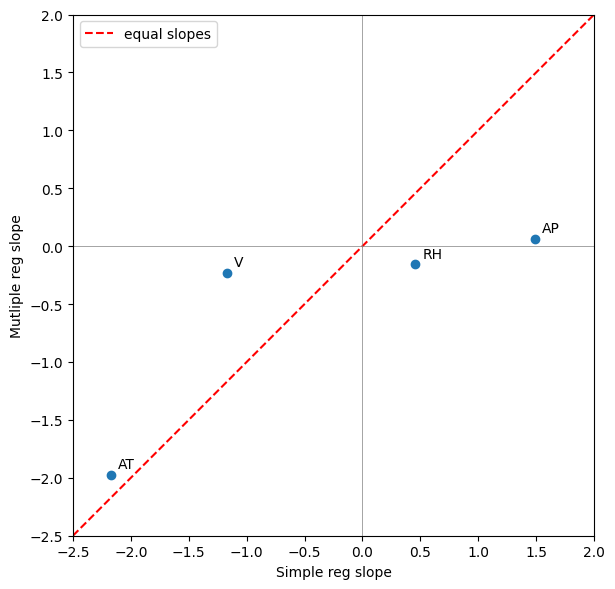

,simple_reg,mult_reg
AT,-2.171,-1.978
V,-1.168,-0.2339
AP,1.49,0.06208
RH,0.4557,-0.1581


In [10]:
frame = pd.DataFrame({
    "simple_reg": table["Slope"],
    "mult_reg": mlr.params[predictors],

})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(frame["simple_reg"], frame["mult_reg"])

for name, row in frame.iterrows():
    ax.annotate(
        name,
        (row["simple_reg"], row["mult_reg"]),
        xytext=(5,5),
        textcoords="offset points",
    )

ax.axline((0,0), slope=1, color="red", linestyle="--", label="equal slopes")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

ax.set_xlabel("Simple reg slope")
ax.set_ylabel("Mutliple reg slope")
ax.set_aspect("equal")
ax.set_xlim(-2.5, 2)
ax.set_ylim(-2.5, 2)
ax.legend()

fig.tight_layout()
plt.show()
display(frame)

Here we actually see RH flip from positive to negative in simple reg to multiple reg, as we had just mentioned. For the other three predictors we have AT, where there's a small shrinkage in magnitude, while V and AP experience a much larger shrinkage in magnitude; however, none of these experience a sign change. 

### 1(f) - Nonlinear association

For each predictor X, fit Y = β0 + β1 X + β2 X² + β3 X³ + ε. Is there evidence of nonlinear association? (footnote 2: sklearn polynomial features)

,Squared term p-value,Cubed term p-value,Cubic R^2,Linear R^2
predictor,,,,
AT,8.833e-73,3.652e-110,0.9119,0.8989
V,0.7685,0.01373,0.775,0.7565
AP,3.667e-17,8.264e-18,0.2749,0.2688
RH,9.395e-06,1.44e-05,0.1537,0.1519


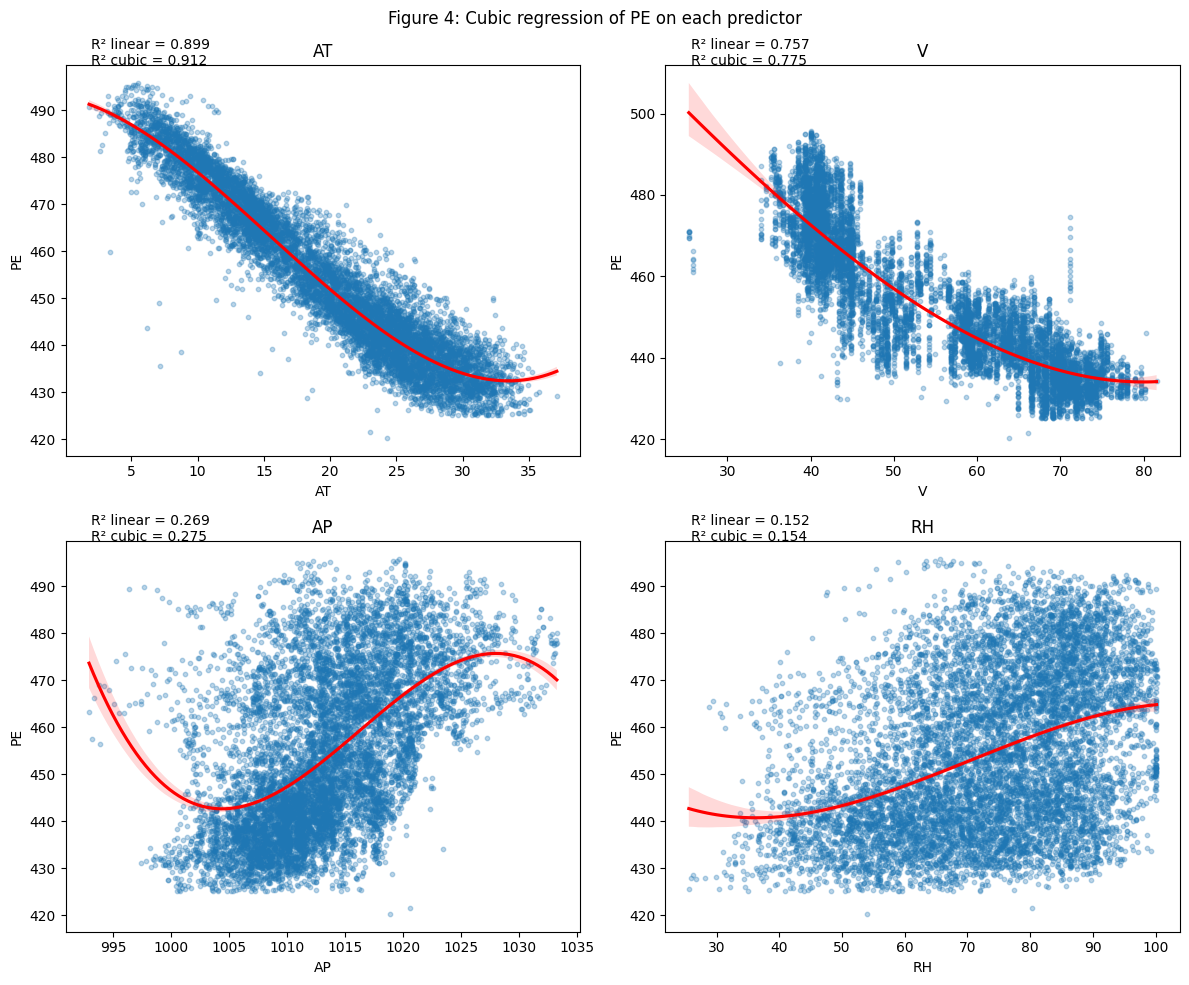

In [11]:
cubic_models = {}
records = {}

for predictor in predictors:
    model = smf.ols(
        f"PE ~ {predictor} + I({predictor}**2) + I({predictor}**3)",
        data=df,
    ).fit()

    cubic_models[predictor] = model
    records[predictor] = {
        "Squared term p-value": model.pvalues[f"I({predictor} ** 2)"],
        "Cubed term p-value": model.pvalues[f"I({predictor} ** 3)"],
        "Cubic R^2": model.rsquared,
        "Linear R^2": table.loc[predictor, "R^2"],
    }

cubic_results = pd.DataFrame.from_dict(records, orient="index")
cubic_results.index.name = "predictor"
display(cubic_results)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle("Figure 4: Cubic regression of PE on each predictor")

for predictor, ax in zip(predictors, axes):
    sns.regplot(
        x=predictor,
        y="PE",
        data=df,
        order=3,
        ax=ax,
        scatter_kws={"s": 10, "alpha": 0.3},
        line_kws={"color": "red"},
    )

    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.set_title(f"{predictor}")
    ax.text(0.05, 1.0,
            f"R² linear = {linear_models[predictor].rsquared:.3f}\nR² cubic = {cubic_models[predictor].rsquared:.3f}",
            transform=ax.transAxes)

fig.tight_layout()
plt.show()


The null hypothesis for each predictor is that the squared and cubic coefficients are both zero. A small p-value on either term would reject that and would be evidence of non-linear association.

AT, AP and RH have both squared and cubic terms that are far below 0.05 as seen in the table above. V is the odd one in this scenario, with the squared term not significant and the cubic term just under 0.05. 

So, yes there is statistical evidence of non-linearity in all four, with AT and AP being the strongest by p-value.

### 1(g) - Pairwise interactions

Full linear regression with all pairwise interaction terms. Are any interaction terms statistically significant?

In [12]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH)**2",
    data=df,
).fit()

print(interaction_model.summary())

# Coefficients and p-values for pairwise interaction terms
interaction_terms = pd.DataFrame({
    "Coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues,
})
interaction_terms = interaction_terms.loc[
    interaction_terms.index.str.contains(":")
]

display(interaction_terms)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:08:36   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,Coefficient,p-value
AT:V,0.02097,3.333e-117
AT:AP,0.001759,0.4521
AT:RH,-0.00523,1.217e-10
V:AP,0.006812,2.877e-07
V:RH,0.0008386,0.08619
AP:RH,-0.001612,0.03361


There are four interaction coefficients with p-values below 0.05, meaning that we would reject the null for them and they are statistically significant interactions. Those would be:
- AT:V
- AT:RH
- V:AP
- AP:RH

The strongest one being AT:V, essentially what this means is that the effect of temperature on output changes depending on the vacuum level. We also see an R-squared of 0.936 which is higher than the value in 1(d) meaning that, by looking at the interactions between these predictors, we're able to better describe PE variation in our model by 0.7 in R-squared. This again shows that the majority of the PE variation predictability is from the predictors themselves. 

### 1(h) - Improving the model

Random 70% train subset. Model 1: all predictors. Model 2: all pairwise interactions + quadratic terms, then remove insignificant variables by p-value (careful with interaction terms). Test both on the remaining 30%, report train and test MSE.

In [13]:
# Split and model 1
train, test = train_test_split(df, test_size=0.3, random_state=SEED)
model_1 = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()

# Model 2: main effects + pairwise interactions + squares
full_formula = (
    "PE ~ (AT + V + AP + RH)**2"
    " + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)"
)
model_2_full = smf.ols(full_formula, data=train).fit()
display(model_2_full.pvalues)


Intercept    9.474e-06
AT             0.01661
V               0.1215
AP           1.454e-06
RH           0.0005091
AT:V         2.484e-05
AT:AP          0.08502
AT:RH        8.319e-05
V:AP            0.2079
V:RH            0.2054
AP:RH        0.0009343
I(AT ** 2)   0.0002414
I(V ** 2)       0.3075
I(AP ** 2)   1.265e-06
I(RH ** 2)   7.056e-10
dtype: float64

In [14]:
# Round 1: V squared has the largest eligible p-value (0.31).
formula = "PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(AP**2) + I(RH**2)"
model_2 = smf.ols(formula, data=train).fit()
display(model_2.pvalues)


Intercept    9.201e-06
AT             0.01062
V               0.1568
AP           1.418e-06
RH           0.0005776
AT:V         8.932e-09
AT:AP          0.05938
AT:RH        0.0001417
V:AP            0.2678
V:RH             0.362
AP:RH         0.001063
I(AT ** 2)   1.106e-07
I(AP ** 2)   1.244e-06
I(RH ** 2)   1.183e-09
dtype: float64

In [15]:
# Round 2: V:RH now has the largest eligible p-value (0.36).
formula = formula + " - V:RH"
model_2 = smf.ols(formula, data=train).fit()
display(model_2.pvalues)


Intercept    1.188e-05
AT            0.004994
V               0.2211
AP           1.854e-06
RH           0.0008819
AT:V         3.968e-10
AT:AP          0.03679
AT:RH        1.077e-07
V:AP            0.3514
AP:RH         0.001607
I(AT ** 2)    1.93e-11
I(AP ** 2)   1.619e-06
I(RH ** 2)   2.185e-10
dtype: float64

In [16]:
# Round 3: V:AP now has the largest eligible p-value (0.35).
formula = formula + " - V:AP"
model_2 = smf.ols(formula, data=train).fit()
display(model_2.pvalues)

#All remaining interactions and squares have p-values below 0.05. All four main effects are still used by retained higher-order terms.


Intercept    1.699e-05
AT           7.751e-08
V            1.224e-50
AP           2.736e-06
RH            0.001406
AT:V         1.128e-10
AT:AP         1.29e-05
AT:RH        1.289e-07
AP:RH         0.002566
I(AT ** 2)   1.024e-13
I(AP ** 2)   2.424e-06
I(RH ** 2)   1.829e-10
dtype: float64

In [17]:
#Training and test MSE for all three models.
records = {}
for name, model in {
    "Model 1: main effects": model_1,
    "Model 2: full": model_2_full,
    "Model 2: pruned": model_2,
}.items():
    records[name] = {
        "Train MSE": mean_squared_error(train["PE"], model.predict(train)),
        "Test MSE": mean_squared_error(test["PE"], model.predict(test)),
    }

results_h = pd.DataFrame.from_dict(records, orient="index")
display(results_h.round(4))


,Train MSE,Test MSE
Model 1: main effects,20.25,21.99
Model 2: full,17.7,19.1
Model 2: pruned,17.7,19.11


The approach here used seed 875 and the removal order of V², V:RH, then V:AP; all based on p-values. The remaining interactions and squares all have p-values below 0.05, meaning the main effects are kept because retained terms use them. Both expanded models have lower test MSE than Model 1, with the full model slightly lower than the pruned model.

So, yes you can improve your model. Our approach removed three terms, starting with the largest p-value and doing one term per round. Test MSE is the number we want to look at because the model has not yet seen that data, and the fact that both models score similarly on train and test says that neither is overfitting too much. 

### 1(i) - KNN regression

KNN regression with raw and with normalized features. Find the best k in {1, ..., 100}. Plot train and test error against 1/k.

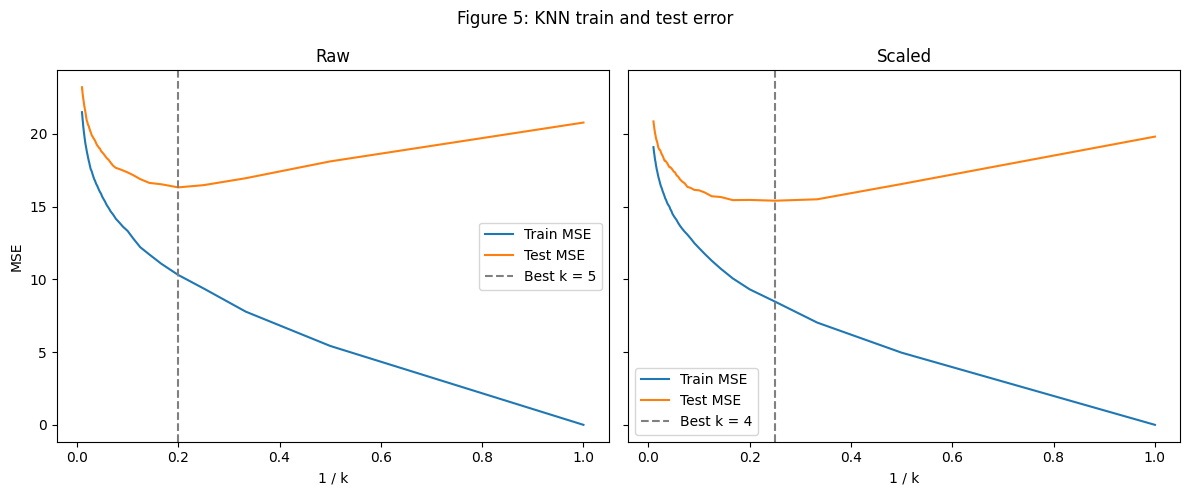

,Best k,Train MSE,Test MSE
Raw,5,10.3,16.32
Scaled,4,8.469,15.4


In [18]:
#Same train/test split as 1(h)

X_train, X_test = train[predictors], test[predictors]
y_train, y_test = train["PE"], test["PE"]

scaler = StandardScaler()

X_train_z = scaler.fit_transform(X_train)
X_test_z = scaler.transform(X_test)
ks = np.arange(1, 101)

def sweep(Xtr, Xte):
    train_errors, test_errors = [], []
    for k in ks:
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(Xtr, y_train)
        train_errors.append(mean_squared_error(y_train, model.predict(Xtr)))
        test_errors.append(mean_squared_error(y_test, model.predict(Xte)))
    return train_errors, test_errors

raw_train, raw_test = sweep(X_train, X_test)
scaled_train, scaled_test = sweep(X_train_z, X_test_z)

errors = {
    "Raw": (raw_train, raw_test),
    "Scaled": (scaled_train, scaled_test),
}

# knn plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for (name, (train_errors, test_errors)), ax in zip(errors.items(), axes):
    best_k = np.argmin(test_errors) + 1
    ax.plot(1 / ks, train_errors, label="Train MSE")
    ax.plot(1 / ks, test_errors, label="Test MSE")
    
    ax.axvline(1 / best_k, color="gray", linestyle="--", label=f"Best k = {best_k}")
    ax.set_title(name)
    ax.set_xlabel("1 / k")
    ax.legend()

axes[0].set_ylabel("MSE")
fig.suptitle("Figure 5: KNN train and test error")
fig.tight_layout()
plt.show()

# table
records = {}
for name, (train_errors, test_errors) in errors.items():
    best_k = np.argmin(test_errors) + 1
    records[name] = {
        "Best k": best_k,
        "Train MSE": train_errors[best_k - 1],
        "Test MSE": test_errors[best_k - 1],
    }

knn_results = pd.DataFrame.from_dict(records, orient="index")
display(knn_results.round(4))   


After performing KNN for this dataset using both normalized and raw features, the lowest test MSE occurs at k = 5 for raw features and k = 4 for scaled features. Meaning that averaging the outputs of the 5 or 4 nearest training observations gives the best predictions among the k values tested.

Scaling helps because k-nearest neighbors uses distances to identify nearby observations and it changes each predictor's values so they're measured on a comparable scale; that being how many standard deviations above or below the training average an observation is.

When using a very small k, the model closely follows individual training observations and produces a lower training error, but it can also pick up noise, resulting in higher test error, meaning overfitting has occurred. Increasing k averages over more neighbors and initially improves test performance, but if k becomes too large, predictions become too smooth and test error rises, meaning underfitting. 

### 1(j) - KNN vs linear regression

Compare KNN with the linear regression model that had the smallest test error. Analysis.

In [19]:
best_linear = results_h.loc[results_h["Test MSE"].idxmin()]

rows = {
    "Best linear": {
        "Train MSE": best_linear["Train MSE"],
        "Test MSE": best_linear["Test MSE"],
    },
    "KNN raw": {
        "Train MSE": knn_results.loc["Raw", "Train MSE"],
        "Test MSE": knn_results.loc["Raw", "Test MSE"],
    },
    "KNN scaled": {
        "Train MSE": knn_results.loc["Scaled", "Train MSE"],
        "Test MSE": knn_results.loc["Scaled", "Test MSE"],
    },
}

comparison = pd.DataFrame.from_dict(rows, orient="index")
comparison["Test RMSE"] = np.sqrt(comparison["Test MSE"])
display(comparison.round(4))


,Train MSE,Test MSE,Test RMSE
Best linear,17.7,19.1,4.371
KNN raw,10.3,16.32,4.04
KNN scaled,8.469,15.4,3.925


The best linear regression is Model 2 with all interactions and squared terms (test MSE 19.1). 

Raw KNN improves on this with test MSE 16.32, and scaled KNN performs best with test MSE 15.4, about 19.4% lower than the best linear model. Scaled KNN test RMSE is about 3.92 MW, compared with 4.37 MW for the best linear model. 

KNN can capture local patterns that the regression formula may miss. On the other hand, scaling changes which observations are considered nearest neighbors. 

I would use scaled KNN with k = 4 to predict PE for new observations under similar plant operating conditions, because it has the lowest test error on this split. If the goal were to describe how the predictors relate to PE using an explicit equation, I would use the model labeled "Best linear" in the table: Model 2 with all interactions and squared terms. Its coefficients provide an equation for PE, although its prediction error is higher than scaled KNN on this split.

Since the models and k were selected using test errors, this is not an independent final evaluation. Before relying on the model for future predictions, I would choose k using cross-validation on the training data and evaluate the selected model on a fresh set of data.


## 2. ISLR 2.4.1

Flexible vs inflexible: better or worse, and why.

### (a) n extremely large, p small

Flexible generally does better in this scenario as lots of data relative to the number of predictors allows for more room to fit a detailed pattern without fitting too much noise. 

### (b) p extremely large, n small

Inflexible works better in this situation, a smaller dataset and a large quantity of predictors means that a flexible method would likely fit random noise in the limited training data.

### (c) highly nonlinear relationship

Flexible works better in this situation as it can follow bending data that a simpler model would miss. 

### (d) Var(ε) extremely high

Neither method can reduce the noise itself in this scenario, but inflexible generally does better. Flexibility can actually end up chasing the noise, distorting the model. 

## 3. ISLR 2.4.7

### (a) Euclidean distance from each observation to the test point (0, 0, 0)

Since the test point is the origin, we square each predictor value, add the squares, and take the square root.


In [20]:
observations = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=pd.Index(range(1, 7), name="Observation"))

observations["Distance"] = np.sqrt(
    observations["X1"]**2 + observations["X2"]**2 + observations["X3"]**2
)
observations["Exact distance"] = ["3", "2", "sqrt(10)", "sqrt(5)", "sqrt(2)", "sqrt(3)"]
display(observations.round(4))


,X1,X2,X3,Y,Distance,Exact distance
Observation,,,,,,
1,0,3,0,Red,3,3
2,2,0,0,Red,2,2
3,0,1,3,Red,3.162,sqrt(10)
4,0,1,2,Green,2.236,sqrt(5)
5,-1,0,1,Green,1.414,sqrt(2)
6,1,1,1,Red,1.732,sqrt(3)


### (b) Prediction with K = 1

The prediction is Green. Observation 5 is the closest point, with distance $\sqrt{2} \approx 1.4142$, and its response is Green. With K = 1, we use the class of that single nearest neighbor.

### (c) Prediction with K = 3

Red is the prediction. The three nearest neighbors, in order, are observation 5 (Green, distance $\sqrt{2}$), observation 6 (Red, distance $\sqrt{3}$), and observation 2 (Red, distance 2). Two of the three neighbors are Red, so Red wins.

### (d) Highly nonlinear Bayes decision boundary: large or small K?

We would expect a small K to work better since it uses nearby observations and gives a more flexible decision boundary that can follow a highly nonlinear pattern.
 
A large K votes across a wider neighborhood, smoothing the boundary and potentially missing those bends. However, making K too small can fit noise, so the best value should be selected using validation data or cross-validation.


### References

**Data**
- UCI Machine Learning Repository, Combined Cycle Power Plant Data Set: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant. Variable descriptions from `data/CCPP/Readme.txt`, which cites Tüfekci (2014) and Kaya, Tüfekci & Gürgen (2012).

**Course material**
- Lesson 1 slides, p. 90: KNN averaging and the choice of k.
- Lesson 2 slides, pp. 28–41: null hypothesis, t-statistic, p-value, and the α = 0.05 decision; pp. 85–86: backward selection by p-value; pp. 98–111: interactions and keeping main effects with their interactions; p. 115: polynomial terms.
- Lesson 4 slides: role of the test set vs. cross-validation for choosing k.
- James, Witten, Hastie & Tibshirani, *An Introduction to Statistical Learning*, ch. 2 (flexibility, bias–variance, KNN; exercises 2.4.1 and 2.4.7) and ch. 3 (linear regression, interactions, polynomial terms).

**Library documentation**
- statsmodels: `OLS`, `formula.api.ols` (formula syntax, `I()` terms, `**2` expansion, `center()`), fitted-result attributes `params`, `pvalues`, `tvalues`, `rsquared`, `predict`.
- seaborn: `pairplot` (`corner`, `plot_kws`, `map_lower`), `regplot` (`order`, `scatter_kws`, `line_kws`).
- pandas: `describe`, `DataFrame.from_dict`, `iterrows`.
- matplotlib: `axline`, `annotate`, `text` with `transform=ax.transAxes`, `set_aspect`.
- scikit-learn: `train_test_split`, `StandardScaler`, `KNeighborsRegressor`, `mean_squared_error`, and the polynomial-features page from footnote 2: https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features

**AI use**

I used Claude by Anthropic as a tutor while writing this notebook. All code cells and written answers were typed by me. 

Specifically, the assistant:
- explained library functions and their arguments (pairplot, regplot, describe, the statsmodels formula interface, StandardScaler, axline);
- explained concepts I asked about (the null hypothesis and t vs. p-values, why p-values print as 0, R² vs. significance, why RH's coefficient changes sign between 1(c) and 1(d), bias–variance in KNN);
- supplied short generic snippets that I used directly: the `add_r` helper on the pairplot in 1(b), the three-line `describe()` + `.loc` summary table in 1(b)(iii), and the `axline`/`annotate`/`set_aspect` calls in 1(e);
- generated the empty section skeleton of this notebook (headings and question text) that I filled in.